# Notebook 03: Model 1: Soft Sensor for Final Moisture

**Project:** MAP Dryer AI  
**Purpose:** compare regression models that estimate `final_moisture_h₂o` from MAP dryer process measurements before the laboratory result is available.

A soft sensor is a model-based estimate of a difficult or delayed measurement. Here, it uses operational variables such as temperatures, air flow, feed rate, residence time, vacuum, pressure, fan speed, and engineered process features.

## Inputs and evaluation approach

- **Input:** `data/processed/dryerMAP_prototype_processed.csv` (created in Notebook 02)
- **Target:** `final_moisture_h₂o`
- **Models compared:** Linear Regression, Ridge Regression, Random Forest, and Gradient Boosting
- **Evaluation:** chronological 80/20 holdout split, followed by time-series cross-validation on the training period
- **Figure outputs:** `figures/03_Model1_SoftSensor/`

The final holdout set is kept separate during model selection so it can provide an unbiased final check.

## 1. Import libraries and locate the project root

Load the modelling, evaluation, visualisation, and interpretation libraries. The project root is found dynamically so the notebook can run from the repository root or the `notebooks/` directory.

In [1]:
from pathlib import Path
import platform
import re
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns
from scipy import stats
import openpyxl
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    max_error
)

import joblib

SRC_DIR = next(
    candidate / "src"
    for candidate in [Path.cwd(), *Path.cwd().parents]
    if (candidate / "data" / "raw").is_dir()
)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from data.project_paths import find_project_root

PROJECT_ROOT = find_project_root()
FIGURES_DIR = PROJECT_ROOT / "figures"
FIGURE_OUTPUT_DIR = FIGURES_DIR / "03_Model1_SoftSensor"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load the processed feature table

Read the dataset prepared in Notebook 02 and parse its temporal columns. This is the feature table used throughout the modelling workflow.

In [4]:
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "dryerMAP_prototype_processed.csv"

dryerMAP_model = pd.read_csv(
    DATA_PATH,
    parse_dates=["date", "timestamp"]
)

dryerMAP_model["time"] = dryerMAP_model["time"].astype(str)

display(dryerMAP_model.head())
dryerMAP_model.info()

,date,time,dryer_air_temperature,cooler_air_temperature,air_flow_rate,wet_product_feed_rate,product_inlet_temperature,residence_time,vacuum,steam_pressure,fan_speed,product_density,final_product_temp,final_moisture_h₂o,timestamp,temperature_drop,air_product_delta,air_per_feed,heating_index,steam_temp_interaction
0,2026-05-01,01:00:00,140.8,18.0,19.95,9.73,61.1,23.08,-0.98,4.20,78.9,1.021,45.6,0.081,2026-05-01 01:00:00,95.2,79.7,2.050360,3249.664,591.360
1,2026-05-01,03:00:00,139.6,22.8,19.94,9.82,61.2,21.95,-1.00,4.27,79.7,1.027,43.8,0.115,2026-05-01 03:00:00,95.8,78.4,2.030550,3064.220,596.092
2,2026-05-01,05:00:00,140.4,23.6,20.98,9.62,63.2,21.79,-1.01,4.13,82.1,1.026,43.1,0.084,2026-05-01 05:00:00,97.3,77.2,2.180873,3059.316,579.852
3,2026-05-01,07:00:00,138.7,24.7,20.05,10.31,64.3,20.94,-1.13,4.13,83.1,1.024,44.5,0.105,2026-05-01 07:00:00,94.2,74.4,1.944714,2904.378,572.831
4,2026-05-01,09:00:00,141.0,26.7,19.72,10.11,63.0,21.89,-0.98,4.66,82.8,1.030,46.5,0.083,2026-05-01 09:00:00,94.5,78.0,1.950544,3086.490,657.060


<class 'pandas.DataFrame'>
RangeIndex: 1051 entries, 0 to 1050
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   date                       1051 non-null   datetime64[us]
 1   time                       1051 non-null   str           
 2   dryer_air_temperature      1051 non-null   float64       
 3   cooler_air_temperature     1051 non-null   float64       
 4   air_flow_rate              1051 non-null   float64       
 5   wet_product_feed_rate      1051 non-null   float64       
 6   product_inlet_temperature  1051 non-null   float64       
 7   residence_time             1051 non-null   float64       
 8   vacuum                     1051 non-null   float64       
 9   steam_pressure             1051 non-null   float64       
 10  fan_speed                  1051 non-null   float64       
 11  product_density            1051 non-null   float64       
 12  final_product_tem

## 3. Review the modelling dataset

Confirm the number of observations and columns, then inspect descriptive statistics before defining the prediction task.

In [5]:
print(f"Rows: {dryerMAP_model.shape[0]}")
print(f"Columns: {dryerMAP_model.shape[1]}")

from stats.descriptive_statistics import descriptive_summary

descriptive_summary(dryerMAP_model)

Rows: 1051
Columns: 20


,count,mean,std,variance,min,25%,50%,75%,max,skewness,excess_kurtosis
dryer_air_temperature,1051.0,140.015699,1.655326,2.740106,134.30000,138.900000,140.000000,141.1000,145.400000,0.054304,-0.012486
cooler_air_temperature,1051.0,25.080400,3.614578,13.065177,18.00000,22.000000,25.100000,28.1000,33.800000,0.010225,-1.039807
air_flow_rate,1051.0,20.384006,0.932393,0.869356,17.01000,19.730000,20.370000,20.9950,23.310000,0.156336,0.016688
wet_product_feed_rate,1051.0,9.918915,0.615243,0.378524,8.17000,9.490000,9.890000,10.3650,11.550000,0.067101,-0.403229
product_inlet_temperature,1051.0,62.305519,2.164279,4.684103,55.50000,60.900000,62.200000,63.8000,68.500000,-0.070309,0.046259
residence_time,1051.0,21.697545,0.827345,0.684499,19.19000,21.160000,21.690000,22.2650,24.370000,-0.048843,-0.165014
vacuum,1051.0,-1.119210,0.140782,0.019819,-1.54000,-1.220000,-1.110000,-1.0200,-0.680000,-0.075009,-0.003649
steam_pressure,1051.0,4.299715,0.316298,0.100044,3.30000,4.090000,4.300000,4.5100,5.480000,-0.020014,-0.078334
fan_speed,1051.0,80.612274,3.548893,12.594640,70.70000,78.100000,80.500000,83.1000,92.900000,0.132046,-0.123379
product_density,1051.0,1.025467,0.007470,0.000056,1.00300,1.020000,1.025000,1.0300,1.050000,0.028723,-0.044147


## 4. Define the prediction target and candidate features

The target is final moisture. The feature list combines direct process measurements with the engineered variables created in Notebook 02. Keeping this list explicit makes the soft-sensor inputs auditable.

In [8]:
TARGET = "final_moisture_h₂o"
FEATURES = [
    "dryer_air_temperature",
    "cooler_air_temperature",
    "air_flow_rate",
    "wet_product_feed_rate",
    "product_inlet_temperature",
    "residence_time",
    "vacuum",
    "steam_pressure",
    "fan_speed",
    "product_density",
    "final_product_temp",
    "temperature_drop",
    "air_product_delta",
    "air_per_feed",
    "steam_temp_interaction",
    "heating_index"
]

## 5. Build the feature matrix and target vector

Separate the selected predictors (`X`) from the laboratory moisture target (`y`) and confirm their dimensions.

In [9]:
X = dryerMAP_model[FEATURES]

y = dryerMAP_model[TARGET]

print(X.shape)
print(y.shape)

(1051, 16)
(1051,)


## 6. Create a chronological train/test split

The first 80% of rows are used for development and the final 20% are reserved for testing. This preserves the dataset order and better reflects a forward-looking production prediction setting than a random split.

In [10]:
split_index = int(len(dryerMAP_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples :", len(X_train))
print("Testing samples  :", len(X_test))

Training samples : 840
Testing samples  : 211


## 7. Scale inputs for linear models

Standardisation is fitted only on the training data and then applied to the test data. Tree-based models below use the original, unscaled features because they do not require scaling.

In [11]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index,
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index,
)

print("Training features standardized:", X_train_scaled.shape)
print("Testing features standardized:", X_test_scaled.shape)

Training features standardized: (840, 16)
Testing features standardized: (211, 16)


## 8. Baseline model 1: Linear Regression

Train a simple linear baseline, calculate holdout metrics, and inspect residual errors over time. This establishes a transparent reference point for the more flexible models.

In [12]:
baseline_linear_model = LinearRegression()
baseline_linear_model.fit(X_train_scaled, y_train)

y_pred_linear = baseline_linear_model.predict(X_test_scaled)

print("Linear Regression baseline trained.")

Linear Regression baseline trained.


In [13]:
baseline_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_linear)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_linear))],
        "R²": [r2_score(y_test, y_pred_linear)],
        "Maximum absolute error": [max_error(y_test, y_pred_linear)],
    },
    index=["Linear Regression"],
)

display(baseline_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Linear Regression,0.0103,0.0132,0.3998,0.054


C:\Users\pc\AppData\Local\Temp\ipykernel_4480\2133664911.py:11: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(error_analysis_linear.round(4))


,timestamp,Actual moisture,Predicted moisture,Residual (actual - predicted),Absolute error
840,2026-07-11 17:00:00,0.103,0.0976,0.0054,0.0054
841,2026-07-11 19:00:00,0.104,0.0949,0.0091,0.0091
842,2026-07-11 21:00:00,0.076,0.0929,-0.0169,0.0169
843,2026-07-11 23:00:00,0.066,0.0856,-0.0196,0.0196
844,2026-07-12 01:00:00,0.105,0.0982,0.0068,0.0068
...,...,...,...,...,...
1046,2026-07-29 15:00:00,0.095,0.0920,0.0030,0.0030
1047,2026-07-29 17:00:00,0.100,0.0888,0.0112,0.0112
1048,2026-07-29 19:00:00,0.112,0.1081,0.0039,0.0039
1049,2026-07-29 21:00:00,0.112,0.0818,0.0302,0.0302


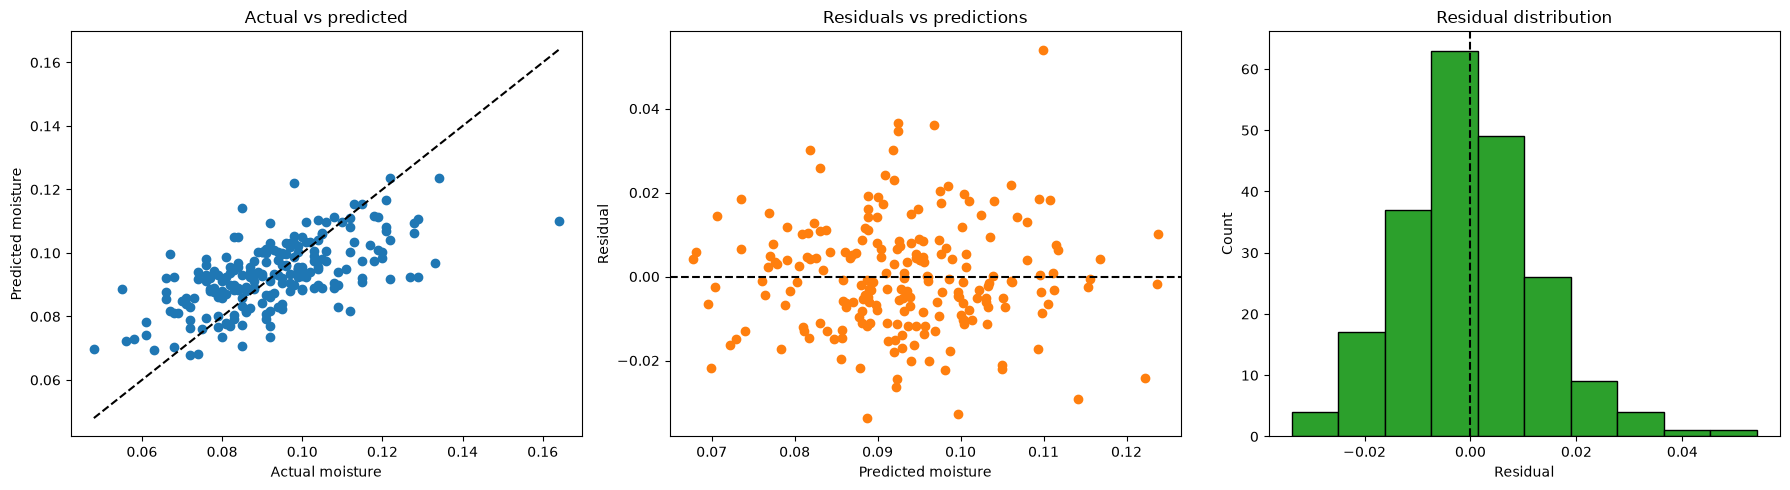

In [15]:
residuals_linear = y_test - y_pred_linear
error_analysis_linear = pd.DataFrame(
    {
        "timestamp": dryerMAP_model.loc[y_test.index, "timestamp"],
        "Actual moisture": y_test,
        "Predicted moisture": y_pred_linear,
        "Residual (actual - predicted)": residuals_linear,
        "Absolute error": residuals_linear.abs(),
    }
)
display(error_analysis_linear.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("MAP Dryer Soft Sensor: Linear Regression Residual Diagnostics", y=1.04)

axis_min = min(y_test.min(), y_pred_linear.min())
axis_max = max(y_test.max(), y_pred_linear.max())
axes[0].scatter(y_test, y_pred_linear, color="tab:blue")
axes[0].plot([axis_min, axis_max], [axis_min, axis_max], "k--")
axes[0].set(xlabel="Actual moisture", ylabel="Predicted moisture", title="Actual vs. Predicted Final Moisture")

axes[1].scatter(y_pred_linear, residuals_linear, color="tab:orange")
axes[1].axhline(0, color="k", linestyle="--")
axes[1].set(xlabel="Predicted moisture", ylabel="Residual", title="Residuals vs. Predicted Moisture")

axes[2].hist(residuals_linear, bins=min(10, len(residuals_linear)), color="tab:green", edgecolor="black")
axes[2].axvline(0, color="k", linestyle="--")
axes[2].set(xlabel="Residual", ylabel="Count", title="Residual Distribution")

fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(
    FIGURE_OUTPUT_DIR / "01_linear_regression_residual_diagnostics.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 9. Baseline model 2: Ridge Regression

Fit a regularised linear model and evaluate it on the same untouched holdout period. Ridge regression can reduce instability when predictor variables are correlated.

In [16]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

print("Ridge baseline trained.")

Ridge baseline trained.


In [17]:
ridge_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_ridge)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_ridge))],
        "R²": [r2_score(y_test, y_pred_ridge)],
        "Maximum absolute error": [max_error(y_test, y_pred_ridge)],
    },
    index=["Ridge Regression"],
)

display(ridge_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Ridge Regression,0.0102,0.0132,0.4031,0.0541


## 10. Baseline model 3: Random Forest

Train an ensemble of decision trees to capture nonlinear relationships and interactions among the dryer variables, then calculate the same holdout metrics for a fair comparison.

In [18]:
random_forest_model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
)

random_forest_model.fit(X_train, y_train)
y_pred_random_forest = random_forest_model.predict(X_test)

print("Random Forest baseline trained.")

Random Forest baseline trained.


In [19]:
random_forest_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_random_forest)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_random_forest))],
        "R²": [r2_score(y_test, y_pred_random_forest)],
        "Maximum absolute error": [max_error(y_test, y_pred_random_forest)],
    },
    index=["Random Forest"],
)

display(random_forest_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Random Forest,0.011,0.0144,0.2915,0.0618


## 11. Baseline model 4: Gradient Boosting

Train a boosting model that builds small decision trees sequentially. Its performance is evaluated with the same holdout set and error measures as the other candidates.

In [20]:
gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=2,
    random_state=42,
)

gradient_boosting_model.fit(X_train, y_train)
y_pred_gradient_boosting = gradient_boosting_model.predict(X_test)

print("Gradient Boosting baseline trained.")

Gradient Boosting baseline trained.


In [21]:
gradient_boosting_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_gradient_boosting)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_gradient_boosting))],
        "R²": [r2_score(y_test, y_pred_gradient_boosting)],
        "Maximum absolute error": [max_error(y_test, y_pred_gradient_boosting)],
    },
    index=["Gradient Boosting"],
)

display(gradient_boosting_metrics.round(4))

,MAE,RMSE,R²,Maximum absolute error
Gradient Boosting,0.0107,0.014,0.3246,0.0602


## 12. Compare baseline results

Rank the four baseline models by RMSE. This is an initial comparison only; the next steps use time-series cross-validation and tuning within the training period before selecting the final candidate.

In [22]:
model_comparison = pd.concat(
    [
        baseline_metrics,
        ridge_metrics,
        random_forest_metrics,
        gradient_boosting_metrics,
    ]
).sort_values("RMSE")

display(model_comparison.round(4))
print(f"Best current model by RMSE: {model_comparison.index[0]}")

,MAE,RMSE,R²,Maximum absolute error
Ridge Regression,0.0102,0.0132,0.4031,0.0541
Linear Regression,0.0103,0.0132,0.3998,0.0540
Gradient Boosting,0.0107,0.0140,0.3246,0.0602
Random Forest,0.0110,0.0144,0.2915,0.0618


Best current model by RMSE: Ridge Regression


## 13. Validate with time-series cross-validation

Use expanding time-series splits within the training data to estimate how each model performs across multiple forward-looking validation periods. MAE, RMSE, and R² are reported for each candidate.

In [23]:
from sklearn.model_selection import GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline

tscv = TimeSeriesSplit(n_splits=3)
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R²": "r2",
}

cv_models = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression": Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))]),
    "Random Forest": RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42
    ),
}

cv_rows = []
for model_name, model in cv_models.items():
    scores = cross_validate(model, X_train, y_train, cv=tscv, scoring=scoring)
    cv_rows.append(
        {
            "Model": model_name,
            "CV MAE": -scores["test_MAE"].mean(),
            "CV RMSE": -scores["test_RMSE"].mean(),
            "CV R²": scores["test_R²"].mean(),
        }
    )

cross_validation_results = (
    pd.DataFrame(cv_rows).set_index("Model").sort_values("CV RMSE")
)
display(cross_validation_results.round(4))

,CV MAE,CV RMSE,CV R²
Model,,,
Ridge Regression,0.0095,0.0129,0.4302
Linear Regression,0.0095,0.0129,0.4260
Gradient Boosting,0.0103,0.0137,0.3597
Random Forest,0.0102,0.0138,0.3488


## 14. Tune the nonlinear and regularised candidates

Use grid search with the same time-series cross-validation strategy to test a small, interpretable set of hyperparameter choices for Ridge, Random Forest, and Gradient Boosting.

In [24]:
tuning_searches = {
    "Ridge Regression": GridSearchCV(
        Pipeline([("scaler", StandardScaler()), ("model", Ridge())]),
        param_grid={"model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
        scoring="neg_root_mean_squared_error",
        cv=tscv,
    ),
    "Random Forest": GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=1),
        param_grid={
            "n_estimators": [100, 200],
            "max_depth": [None, 3],
            "min_samples_leaf": [1, 2],
        },
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
    ),
    "Gradient Boosting": GridSearchCV(
        GradientBoostingRegressor(random_state=42),
        param_grid={
            "n_estimators": [50, 100],
            "learning_rate": [0.03, 0.05],
            "max_depth": [1, 2],
        },
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1,
    ),
}

tuning_rows = []
for model_name, search in tuning_searches.items():
    search.fit(X_train, y_train)
    tuning_rows.append(
        {
            "Model": model_name,
            "Best CV RMSE": -search.best_score_,
            "Best parameters": search.best_params_,
        }
    )

tuning_results = (
    pd.DataFrame(tuning_rows).set_index("Model").sort_values("Best CV RMSE")
)
display(tuning_results)

,Best CV RMSE,Best parameters
Model,,
Ridge Regression,0.012867,{'model__alpha': 0.1}
Gradient Boosting,0.013660,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est..."
Random Forest,0.013735,"{'max_depth': None, 'min_samples_leaf': 2, 'n_..."


## 15. Select and refit the final candidate

Choose the candidate with the lowest cross-validation RMSE, then fit that selected model on the complete training period. The chronological test set remains untouched until the final evaluation.

In [25]:
selection_results = pd.concat(
    [
        pd.DataFrame(
            {"Selection CV RMSE": [cross_validation_results.loc["Linear Regression", "CV RMSE"]]},
            index=["Linear Regression"],
        ),
        tuning_results[["Best CV RMSE"]].rename(
            columns={"Best CV RMSE": "Selection CV RMSE"}
        ),
    ]
).sort_values("Selection CV RMSE")

final_model_name = selection_results.index[0]
final_model_candidates = {
    "Linear Regression": Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    "Ridge Regression": tuning_searches["Ridge Regression"].best_estimator_,
    "Random Forest": tuning_searches["Random Forest"].best_estimator_,
    "Gradient Boosting": tuning_searches["Gradient Boosting"].best_estimator_,
}

final_model = final_model_candidates[final_model_name]
final_model.fit(X_train, y_train)

display(selection_results.round(4))
print(
    f"Selected final candidate: {final_model_name}. "
    "The chronological test set remains untouched for Task 20."
)

,Selection CV RMSE
Ridge Regression,0.0129
Linear Regression,0.0129
Gradient Boosting,0.0137
Random Forest,0.0137


Selected final candidate: Ridge Regression. The chronological test set remains untouched for Task 20.


## 16. Inspect global feature importance

Rank the influence of input features in the selected model. For tree models this is impurity-based importance; for linear models it is the absolute standardised coefficient. These scores describe model behaviour, not causal effects.

,Feature,Importance
0,wet_product_feed_rate,0.023310
1,heating_index,0.021976
2,residence_time,0.018212
3,air_flow_rate,0.012215
4,air_per_feed,0.011578
5,product_inlet_temperature,0.003395
6,dryer_air_temperature,0.002069
7,fan_speed,0.001930
8,steam_pressure,0.001695
9,air_product_delta,0.001544


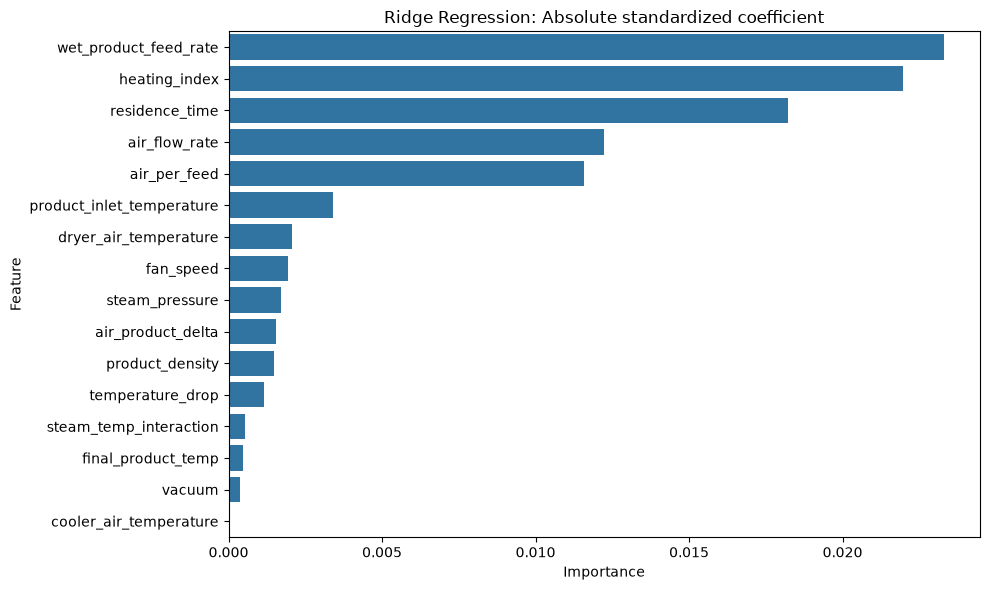

In [26]:
final_estimator = (
    final_model.named_steps["model"]
    if isinstance(final_model, Pipeline)
    else final_model
)

if hasattr(final_estimator, "feature_importances_"):
    importance_values = final_estimator.feature_importances_
    importance_method = "Impurity-based feature importance"
elif hasattr(final_estimator, "coef_"):
    importance_values = np.abs(np.ravel(final_estimator.coef_))
    importance_method = "Absolute standardized coefficient"
else:
    raise TypeError(f"Feature importance is not available for {final_model_name}.")

feature_importance = (
    pd.DataFrame({"Feature": X_train.columns, "Importance": importance_values})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x="Importance", y="Feature", color="tab:blue")
plt.title(f"MAP Dryer Soft Sensor: {final_model_name}\n{importance_method}")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "02_selected_model_feature_importance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 17. Explain predictions with SHAP

SHAP summaries show how strongly each feature contributes to the selected model's predictions across the training data. Use them to understand model patterns, while keeping normal process-engineering validation in the loop.

c:\Users\pc\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 840 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=840 when initializing the masker.


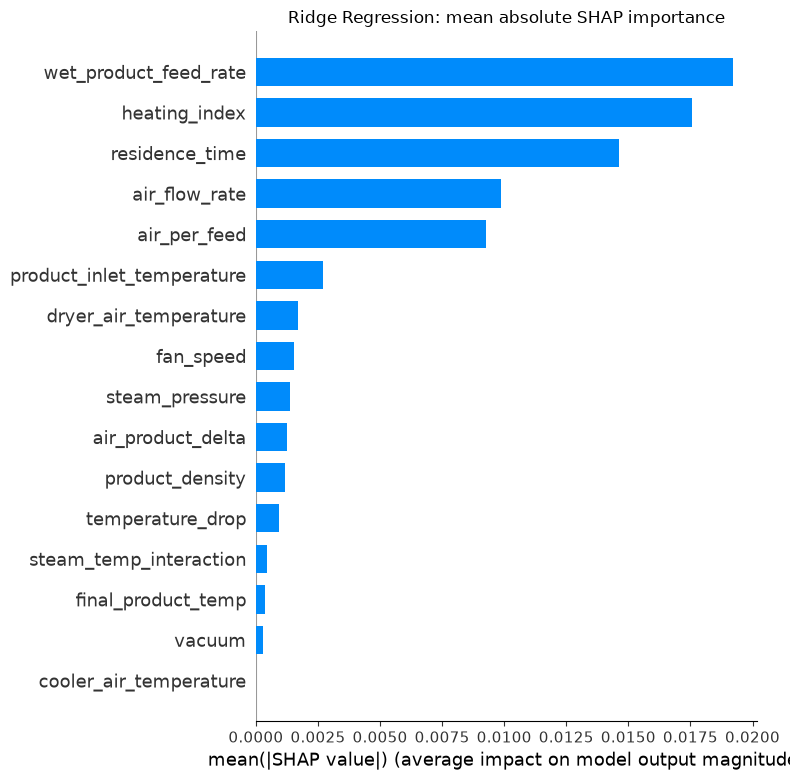

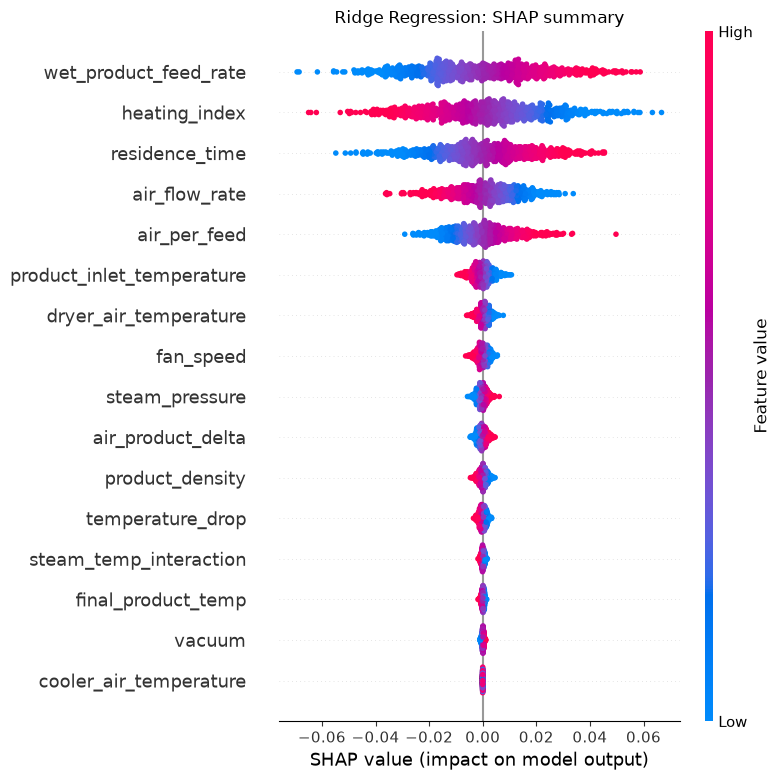

In [27]:
import shap

if hasattr(final_estimator, "feature_importances_"):
    X_explain = X_train
    shap_explainer = shap.TreeExplainer(final_estimator)
    shap_values = shap_explainer.shap_values(X_explain)
elif isinstance(final_model, Pipeline) and "scaler" in final_model.named_steps:
    X_explain = pd.DataFrame(
        final_model.named_steps["scaler"].transform(X_train),
        columns=X_train.columns,
        index=X_train.index,
    )
    shap_explainer = shap.LinearExplainer(final_estimator, X_explain)
    shap_values = shap_explainer.shap_values(X_explain)
else:
    X_explain = X_train
    shap_explainer = shap.LinearExplainer(final_estimator, X_explain)
    shap_values = shap_explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain, plot_type="bar", show=False)
plt.title(f"MAP Dryer Soft Sensor: {final_model_name} ? Mean Absolute SHAP Importance")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "03_selected_model_shap_global_importance.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

shap.summary_plot(shap_values, X_explain, show=False)
plt.title(f"MAP Dryer Soft Sensor: {final_model_name} ? SHAP Summary")
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "04_selected_model_shap_summary.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## 18. Final evaluation on the untouched test period

Evaluate the selected model once on the held-out chronological test set using MAE, RMSE, R², and maximum absolute error. The time-series plot compares predicted and actual final moisture over that period.

,MAE,RMSE,R²,Maximum absolute error
Ridge Regression,0.0103,0.0132,0.402,0.0537


C:\Users\pc\AppData\Local\Temp\ipykernel_4480\574849324.py:23: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(final_test_predictions.round(4))


,timestamp,Actual moisture,Predicted moisture,Residual (actual - predicted)
840,2026-07-11 17:00:00,0.103,0.0977,0.0053
841,2026-07-11 19:00:00,0.104,0.0946,0.0094
842,2026-07-11 21:00:00,0.076,0.0928,-0.0168
843,2026-07-11 23:00:00,0.066,0.0856,-0.0196
844,2026-07-12 01:00:00,0.105,0.0980,0.0070
...,...,...,...,...
1046,2026-07-29 15:00:00,0.095,0.0921,0.0029
1047,2026-07-29 17:00:00,0.100,0.0881,0.0119
1048,2026-07-29 19:00:00,0.112,0.1074,0.0046
1049,2026-07-29 21:00:00,0.112,0.0818,0.0302


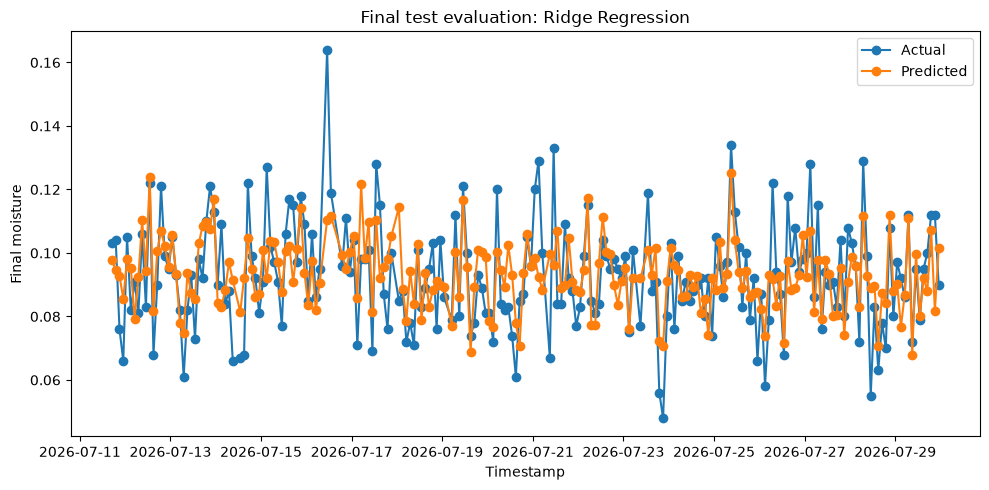

In [30]:
y_pred_final = final_model.predict(X_test)

final_test_metrics = pd.DataFrame(
    {
        "MAE": [mean_absolute_error(y_test, y_pred_final)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_final))],
        "R²": [r2_score(y_test, y_pred_final)],
        "Maximum absolute error": [max_error(y_test, y_pred_final)],
    },
    index=[final_model_name],
)

final_test_predictions = pd.DataFrame(
    {
        "timestamp": dryerMAP_model.loc[y_test.index, "timestamp"],
        "Actual moisture": y_test,
        "Predicted moisture": y_pred_final,
        "Residual (actual - predicted)": y_test - y_pred_final,
    }
)

display(final_test_metrics.round(4))
display(final_test_predictions.round(4))

plt.figure(figsize=(10, 5))
plt.plot(final_test_predictions["timestamp"], final_test_predictions["Actual moisture"], marker="o", label="Actual")
plt.plot(final_test_predictions["timestamp"], final_test_predictions["Predicted moisture"], marker="o", label="Predicted")
plt.title(f"MAP Dryer Soft Sensor: Final Holdout Evaluation ? {final_model_name}")
plt.xlabel("Timestamp")
plt.ylabel("Final Moisture (H?O)")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_OUTPUT_DIR / "05_final_holdout_predictions.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

## Next step

Use these results as the soft-sensor baseline. The later notebooks are reserved for off-spec classification, anomaly detection, and model comparison as the MAP Dryer AI workflow expands.